# Classificador usando o Yolo

In [17]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.4 MB/s eta 0:00:00


In [21]:
from pathlib import Path
from collections import Counter, defaultdict
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import shutil
from ultralytics import YOLO


In [5]:

DATA_PATH = Path('/content/drive/MyDrive/IA/data/human-faces-dataset')


## Análise do Dataset

In [6]:
all_classes = sorted(os.listdir(DATA_PATH))
print("Quantidade de Classes:", len(all_classes))
print("Classes:\n",all_classes)



Quantidade de Classes: 2
Classes:
 ['men', 'women']


 - men: 727 imagens
 - women: 1273 imagens


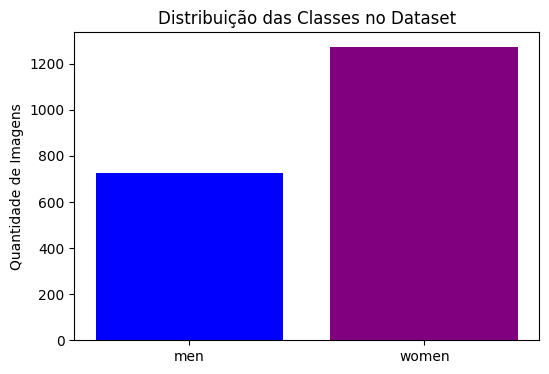

In [7]:
cont_img_class = {}
for c in all_classes:
  path_classe = os.path.join(DATA_PATH, c)
  #extensoes das imagens
  imagens = [f for f in os.listdir(path_classe) if f.lower().endswith(('.png', '.jpg','.jpeg'))]
  cont_img_class[c] = len(imagens)
  print(f" - {c}: {len(imagens)} imagens")

#plotando a distribuição
plt.figure(figsize=(6,4))
plt.bar(cont_img_class.keys(), cont_img_class.values(), color=['blue', 'purple'])
plt.title("Distribuição das Classes no Dataset")
plt.ylabel("Quantidade de Imagens")
plt.show()

In [8]:
#DIMENSÕES DAS IMAGENS
dimensoes = []
for c in all_classes:
  path_classe = os.path.join(DATA_PATH, c)
  #extensoes das imagens
  imagens = [f for f in os.listdir(path_classe) if f.lower().endswith(('.png', '.jpg','.jpeg'))]

  for img_name in imagens[:10]:
    img_path = os.path.join(path_classe, img_name)
    with Image.open(img_path) as img:
      largura, altura = img.size
      dimensoes.append({'classe': c, 'largura':largura, 'altura': altura, 'modo':img.mode})

df_dimensoes = pd.DataFrame(dimensoes)
print(df_dimensoes)

   classe  largura  altura modo
0     men     1024    1024  RGB
1     men     1024    1024  RGB
2     men     1024    1024  RGB
3     men     1024    1024  RGB
4     men     1024    1024  RGB
5     men     1024    1024  RGB
6     men     1024    1024  RGB
7     men     1024    1024  RGB
8     men     1024    1024  RGB
9     men     1024    1024  RGB
10  women     1024    1024  RGB
11  women     1024    1024  RGB
12  women     1024    1024  RGB
13  women     1024    1024  RGB
14  women     1024    1024  RGB
15  women     1024    1024  RGB
16  women     1024    1024  RGB
17  women     1024    1024  RGB
18  women     1024    1024  RGB
19  women     1024    1024  RGB


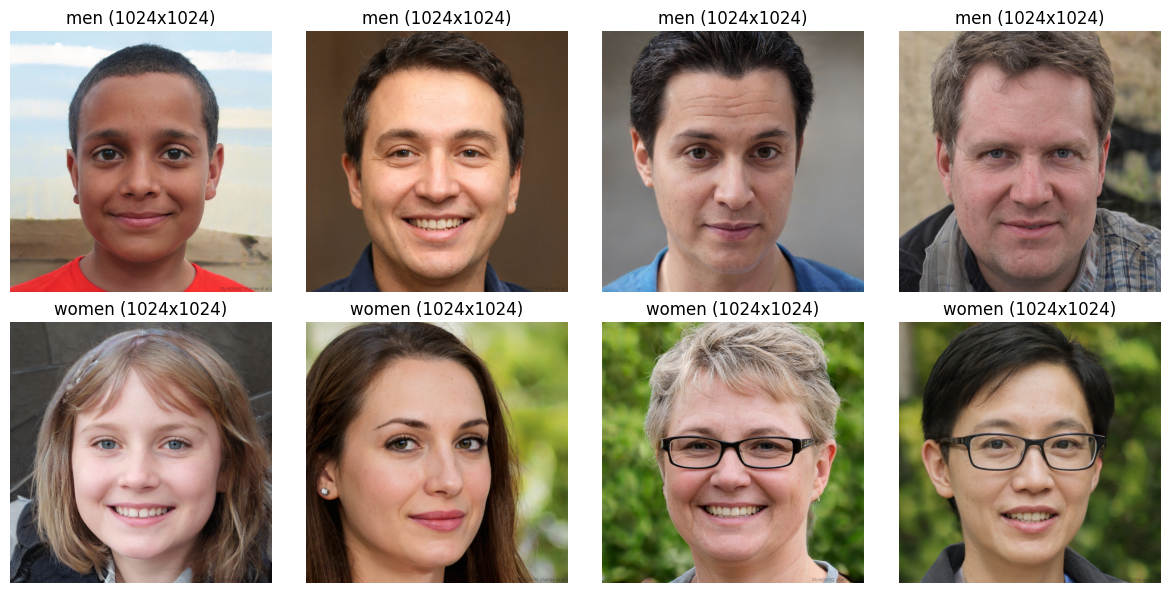

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, c in enumerate(all_classes):
    path_classe = os.path.join(DATA_PATH, c)
    imagens = [f for f in os.listdir(path_classe) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Seleciona 4
    for j in range(4):
        img_path = os.path.join(path_classe, imagens[j])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR para RGB

        ax = axes[i, j]
        ax.imshow(img)
        ax.set_title(f"{c} ({img.shape[1]}x{img.shape[0]})")
        ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
#inventario das imagens
records = []
CLASS_DIRS = [p for p in DATA_PATH.iterdir() if p.is_dir()]
img_ext = {'.png', '.jpg', '.jpeg'}
for class_dir in sorted(CLASS_DIRS, key=lambda p: p.name.lower()):
    current_class = class_dir.name
    for path in class_dir.rglob("*"):
        if path.is_file() and path.suffix.lower() in img_ext:
            records.append({
                "path": str(path),
                "class_name": current_class,
                "filename": path.name,
                "ext": path.suffix.lower(),
                "file_size_bytes": path.stat().st_size,
            })

inventory_df = pd.DataFrame(records)
inventory_df["file_size_kb"] = inventory_df["file_size_bytes"] / 1024

print("Total files found:", len(inventory_df))
display(inventory_df.head())

Total files found: 2000


,path,class_name,filename,ext,file_size_bytes,file_size_kb
0,/content/drive/MyDrive/IA/data/human-faces-dat...,men,image_110.jpg,.jpg,479246,468.013672
1,/content/drive/MyDrive/IA/data/human-faces-dat...,men,image_1016.jpg,.jpg,548902,536.037109
2,/content/drive/MyDrive/IA/data/human-faces-dat...,men,image_1455.jpg,.jpg,528901,516.504883
3,/content/drive/MyDrive/IA/data/human-faces-dat...,men,image_1375.jpg,.jpg,614250,599.853516
4,/content/drive/MyDrive/IA/data/human-faces-dat...,men,image_1397.jpg,.jpg,608232,593.976562


In [11]:
summary_basic = {
    "dataset_root": str(DATA_PATH),
    "n_images": int(len(inventory_df)),
    "n_classes": int(inventory_df["class_name"].nunique()),
    "classes": sorted(inventory_df["class_name"].unique().tolist()),
    "extensions": inventory_df["ext"].value_counts().to_dict(),
}

summary_basic

{'dataset_root': '/content/drive/MyDrive/IA/data/human-faces-dataset',
 'n_images': 2000,
 'n_classes': 2,
 'classes': ['men', 'women'],
 'extensions': {'.jpg': 2000}}

### Discussão:

As classes do dataset estão desbalaceadas, 1:1.75, o que pode afetar o treinamento do modelo de classificação. Além disso, temos imagens com alta resolução, que pode reduzir a velocidade.

### Preparação dos dados para o YOLOV8

In [14]:
#pasta destino
YOLO_DATA_PATH = Path('/content/drive/MyDrive/IA/data/human-faces-yolo')

#divindo os dados entre treino(80%) e validação(20%)
train_df, val_df = train_test_split(
    inventory_df,
    test_size=0.2,
    stratify=inventory_df['class_name'],
    random_state=42
)

#copia os arquivos sob a estrutura yolo
def yolo_folders(df, split_name):
  for _, row, in df.iterrows():
    dest_dir = YOLO_DATA_PATH/split_name/ row['class_name']
    dest_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy(row['path'], dest_dir/row['filename'])

In [15]:
#separando
print("Organizando arquivos para o YOLOv8...")
yolo_folders(train_df, 'train')
yolo_folders(val_df, 'val')

Organizando arquivos para o YOLOv8...


In [19]:
#instaciando o YOLOV8
modelo = YOLO('yolov8n-cls.pt')


In [20]:
#treinando o modelo
resultados = modelo.train(data='/content/drive/MyDrive/IA/data/human-faces-yolo',
                          epochs=30,
                          imgsz=224,
                          batch=32)

Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/IA/data/human-faces-yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

#### validação

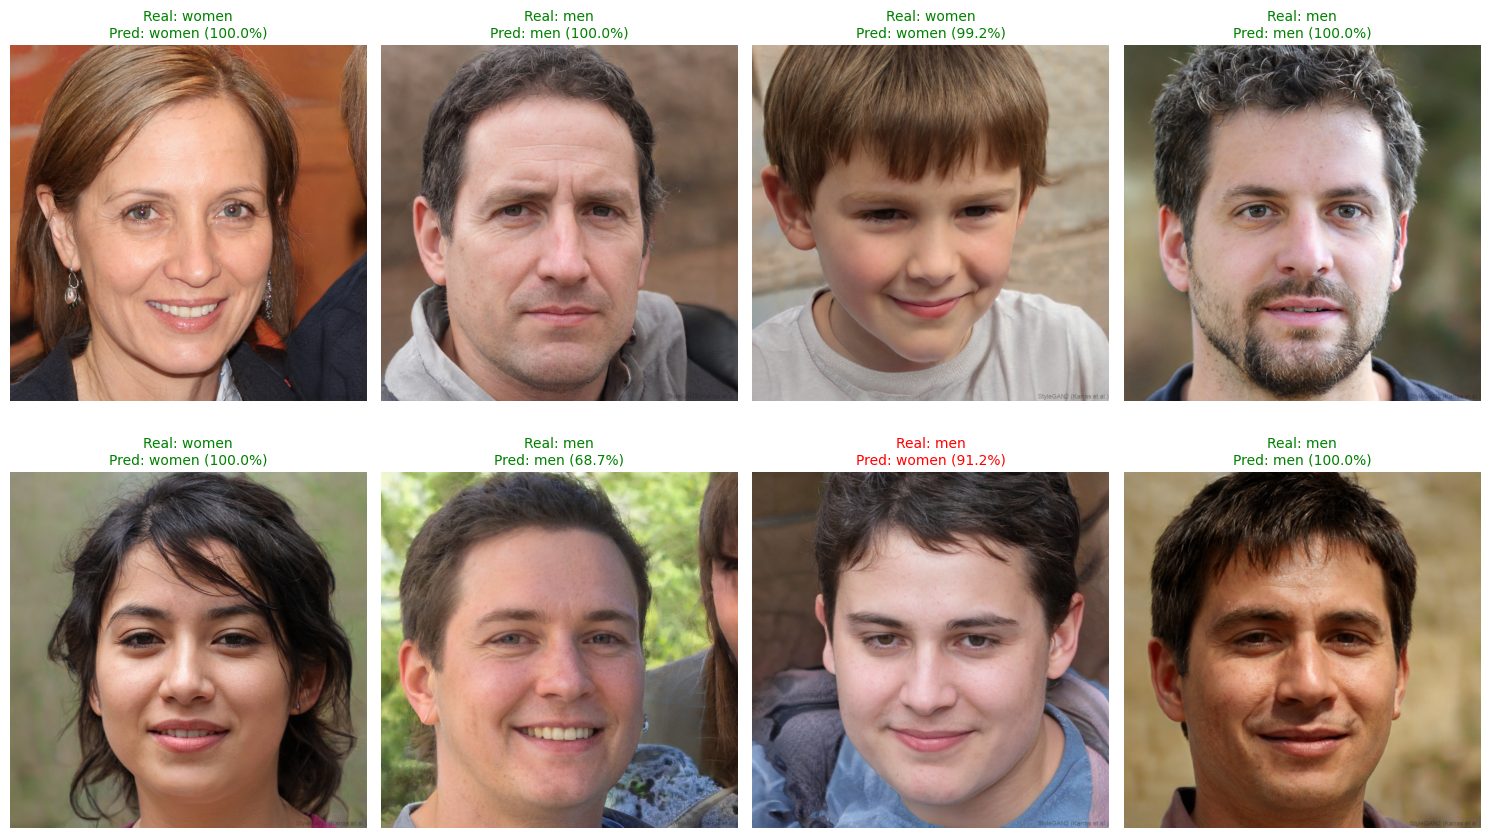

In [26]:
#pega o modelo
model_path = '/content/runs/classify/train/weights/best.pt'
modelo = YOLO(model_path)

val_dir = '/content/drive/MyDrive/IA/data/human-faces-yolo/val'
classes = ['men', 'women']

#visualizando os resultados
fig, axes = plt.subplots(2,4, figsize=(15, 9))
axes = axes.ravel()

for i in range(8):
  #sorteia classes
  class_escol = random.choice(classes)
  pasta_class = os.path.join(val_dir, class_escol)

  #sorteia imagens
  lista_imgs = os.listdir(pasta_class)
  img_sort = random.choice(lista_imgs)
  caminho_img = os.path.join(pasta_class, img_sort)


  #inferencia do modelo
  resultados = modelo(caminho_img, verbose=False)
  resultado = resultados[0]

  #extrai a prob
  probs = resultado.probs
  top_idx = probs.top1
  nome_predict = resultado.names[top_idx]
  conf = probs.top1conf.item()*100

  #carregando a img
  img = cv2.imread(caminho_img)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  #identifica se acertou ou errou
  cor_titulo = 'green' if nome_predict == class_escol else 'red'

  # Plota no grid
  axes[i].imshow(img)
  axes[i].set_title(f"Real: {class_escol}\nPred: {nome_predict} ({conf:.1f}%)", color=cor_titulo, fontsize=10)
  axes[i].axis('off')

plt.tight_layout()
plt.show()


In [27]:
# Roda a classificação no vídeo frame a frame e salva o resultado final gravado
modelo.predict(source="seu_video.mp4", show=False, save=True)

FileNotFoundError: seu_video.mp4 does not exist